In [1]:
import pandas as pd
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import datetime
import QuantLib as ql


In [2]:
eval_date = ql.Date(19, 5, 2026)
calendar = ql.UnitedStates(ql.UnitedStates.NYSE)
day_count = ql.Actual365Fixed()
compounding = ql.Continuous

ql.Settings.instance().evaluationDate = eval_date


In [3]:
fwd_rate = ql.SimpleQuote(0.03)
zero_curve = ql.FlatForward(eval_date, ql.QuoteHandle(fwd_rate), day_count, compounding)
zero_curve_handle = ql.YieldTermStructureHandle(zero_curve)

spot_price_1 = 295.7
spot_price_2 = 195.7
spot_handle_1 = ql.QuoteHandle(ql.SimpleQuote(spot_price_1))
spot_handle_2 = ql.QuoteHandle(ql.SimpleQuote(spot_price_2))

div_pillars = [
    ql.Date(21, 5, 2026),
    ql.Date(19, 6, 2026),
    ql.Date(18, 9, 2026),
    ql.Date(17, 12, 2026)
]

div_curve_1 = ql.ZeroCurve(
    div_pillars, 
    [0.0, 0.10358, 0.07464, 0.05098], 
    day_count, 
    calendar
)

div_curve_2 = ql.ZeroCurve(
    div_pillars, 
    [0.0, 0.15358, 0.09464, 0.08098], 
    day_count, 
    calendar
)


div_curve_1.enableExtrapolation()
div_curve_2.enableExtrapolation()
div_curve_handle_1 = ql.YieldTermStructureHandle(div_curve_1)
div_curve_handle_2 = ql.YieldTermStructureHandle(div_curve_2)

vol_expiry_dates = [
    ql.Date(19, 8, 2026),
    ql.Date(19, 11, 2026),
    ql.Date(19, 2, 2027),
    ql.Date(19, 5, 2027),
    ql.Date(19, 8, 2027),
    ql.Date(19, 11, 2027),
    ql.Date(19, 2, 2028),
    ql.Date(19, 5, 2028)
]

atm_vols_1 = [0.324566, 0.324566, 0.320002, 0.314524, 0.309046, 0.310071, 0.310603, 0.310603]
atm_vols_2 = [v - 0.1 for v in atm_vols_1]

atm_vol_curve_1 = ql.BlackVarianceCurve(
    eval_date, 
    vol_expiry_dates, 
    atm_vols_1, 
    day_count
)

atm_vol_curve_2 = ql.BlackVarianceCurve(
    eval_date, 
    vol_expiry_dates, 
    atm_vols_2, 
    day_count
)

atm_vol_handle_1 = ql.BlackVolTermStructureHandle(atm_vol_curve_1)
atm_vol_handle_2 = ql.BlackVolTermStructureHandle(atm_vol_curve_1)


In [10]:
bsm_process_1 = ql.BlackScholesMertonProcess(
    spot_handle_1, 
    div_curve_handle_1, 
    zero_curve_handle, 
    atm_vol_handle_1
)

bsm_process_2 = ql.BlackScholesMertonProcess(
    spot_handle_2, 
    div_curve_handle_2, 
    zero_curve_handle, 
    atm_vol_handle_2
)

rho = 0.65
corr_matrix = ql.Matrix(2, 2)
corr_matrix[0][0] = 1.0
corr_matrix[0][1] = rho
corr_matrix[1][0] = rho
corr_matrix[1][1] = 1.0

multi_process = ql.StochasticProcessArray(
    [bsm_process_1, bsm_process_2],
    corr_matrix
)


In [11]:
sim_dates = [
    ql.Date(19, 6, 2026),
    ql.Date(18, 9, 2026),
    ql.Date(17, 12, 2026),
    ql.Date(19, 2, 2027),
    ql.Date(19, 5, 2027),
    ql.Date(19, 8, 2027),
    ql.Date(19, 11, 2027),
    ql.Date(19, 2, 2028),
    ql.Date(19, 5, 2028)
]

sim_times = [day_count.yearFraction(eval_date, d) for d in sim_dates]
time_grid = ql.TimeGrid(sim_times, len(sim_times))

n_assets = multi_process.size()
n_steps = len(time_grid) - 1

dimensions = n_assets * n_steps


In [17]:
sobol_urng = ql.UniformLowDiscrepancySequenceGenerator(    
    dimensions,
    0,
    ql.SobolRsg.JoeKuoD7
)

gaussian_rng = ql.GaussianLowDiscrepancySequenceGenerator(sobol_urng)

path_gen = ql.GaussianSobolMultiPathGenerator(
    multi_process, 
    time_grid,
    gaussian_rng, 
    False
)


In [18]:
n_paths = 2 ** 10

paths = np.zeros((n_paths, n_assets, n_steps + 1))

for i in range(n_paths):
    sample     = path_gen.next()
    multi_path = sample.value()          # ql.MultiPath object

    for a in range(n_assets):
        asset_path = multi_path[a]       # ql.Path for asset a
        paths[i, a] = [asset_path[t] for t in range(n_steps + 1)]

# ─── Inspect ─────────────────────────────────────────────────────────
print(f"paths.shape : {paths.shape}")            # (1024, 2, 10)
print(f"Asset 1 path[0]: {np.round(paths[0, 0], 4)}")
print(f"Asset 2 path[0]: {np.round(paths[0, 1], 4)}")
print(f"All Asset 1 start at {spot_price_1}: {np.allclose(paths[:, 0, 0], spot_price_1)}")
print(f"All Asset 2 start at {spot_price_2}: {np.allclose(paths[:, 1, 0], spot_price_2)}")

# ─── Verify realized correlation ─────────────────────────────────────
log_ret1 = np.diff(np.log(paths[:, 0, :]), axis=1)  # (1024, 9)
log_ret2 = np.diff(np.log(paths[:, 1, :]), axis=1)  # (1024, 9)

# Flatten all steps and compute correlation across paths
realized_corr = np.corrcoef(log_ret1.flatten(), log_ret2.flatten())[0, 1]
print(f"\nTarget correlation  : {rho:.4f}")
print(f"Realized correlation: {realized_corr:.4f}")

paths.shape : (1024, 2, 10)
Asset 1 path[0]: [295.7    292.562  286.2871 283.4988 282.8022 282.124  281.6443 280.5516
 279.4932 278.5293]
Asset 2 path[0]: [195.7    192.8135 188.194  184.3605 182.1956 179.4103 176.7137 173.6776
 170.712  167.9007]
All Asset 1 start at 295.7: True
All Asset 2 start at 195.7: True

Target correlation  : 0.6500
Realized correlation: 0.6501


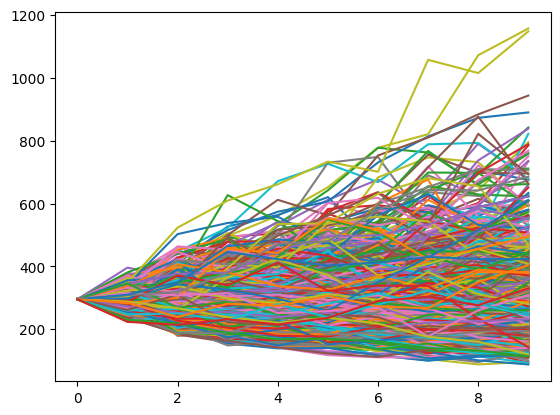

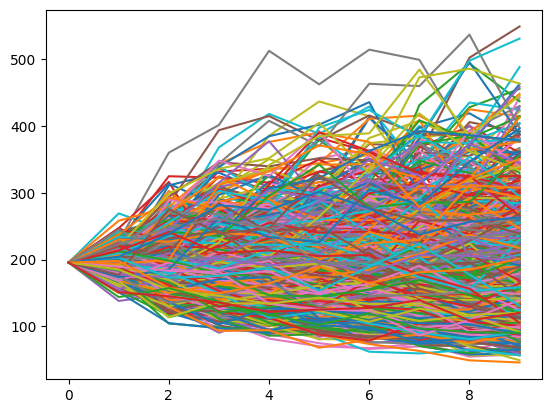

In [22]:
plt.plot(paths[:, 0].T)
plt.show()

plt.plot(paths[:, 1].T)
plt.show()
